# 실전 데이터 분석
- 서울시 자치구 연도별 CCTV 현황
- 서울시 주민등록인구('구'별) 현황 

In [3]:
import numpy as np
import pandas as pd 

In [5]:
!pip install openpyxl

In [6]:
CCTV = pd.read_excel('CCTV.xlsx')

In [7]:
CCTV

,Unnamed: 0,서울시 자치구 (연도별) CCTV 설치 현황,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,"(단위 : 대, '25. 12. 31. 기준)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
2,NaN,계,122613,15219,9222,10188,12635,11384,9390,9014,13935,20270,11356
3,NaN,종로구,3125,38,55,115,45,223,85,225,1026,1041,272
4,NaN,중 구,3427,388,366,384,162,352,404,137,138,582,514
5,NaN,용산구,3801,105,98,65,317,563,400,446,385,649,773
6,NaN,성동구,4790,507,924,454,688,480,361,231,488,368,289
7,NaN,광진구,4872,60,652,464,637,194,739,277,348,1015,486
8,NaN,동대문구,4305,1586,143,195,211,224,181,234,509,572,450
9,NaN,중랑구,5549,337,179,208,1056,987,603,348,689,895,247


In [8]:
CCTV = pd.read_excel('CCTV.xlsx', skiprows=2)

In [9]:
CCTV

,Unnamed: 0,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
0,NaN,계,122613.0,15219.0,9222.0,10188.0,12635.0,11384.0,9390.0,9014.0,13935.0,20270.0,11356.0
1,NaN,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0
2,NaN,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0
3,NaN,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0
4,NaN,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0
5,NaN,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0
6,NaN,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0
7,NaN,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
8,NaN,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
9,NaN,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0


In [10]:
CCTV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   자치구         27 non-null     object 
 2   총 계         26 non-null     float64
 3   2016년 이전    26 non-null     float64
 4   2017년       26 non-null     float64
 5   2018년       26 non-null     float64
 6   2019년       26 non-null     float64
 7   2020년       26 non-null     float64
 8   2021년       26 non-null     float64
 9   2022년       26 non-null     float64
 10  2023년       26 non-null     float64
 11  2024년       26 non-null     float64
 12  2025년       26 non-null     float64
dtypes: float64(12), object(1)
memory usage: 2.9+ KB


In [11]:
del CCTV['Unnamed: 0']

In [12]:
CCTV

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
0,계,122613.0,15219.0,9222.0,10188.0,12635.0,11384.0,9390.0,9014.0,13935.0,20270.0,11356.0
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0
4,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0
5,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0
6,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0
7,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
9,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0


In [13]:
CCTV.drop(26, inplace=True) #26번 인덱스를 삭제하겠다. 

In [14]:
CCTV

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
0,계,122613.0,15219.0,9222.0,10188.0,12635.0,11384.0,9390.0,9014.0,13935.0,20270.0,11356.0
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0
4,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0
5,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0
6,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0
7,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
9,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0


In [15]:
CCTV.drop(0, inplace=True)

In [18]:
CCTV.head(2)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0


In [19]:
CCTV.tail()

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
21,관악구,7202.0,480.0,639.0,662.0,886.0,400.0,550.0,137.0,745.0,1067.0,1636.0
22,서초구,6377.0,1178.0,1019.0,416.0,332.0,415.0,565.0,882.0,469.0,744.0,357.0
23,강남구,8600.0,1741.0,918.0,726.0,807.0,671.0,501.0,603.0,912.0,610.0,1111.0
24,송파구,5002.0,303.0,227.0,516.0,1052.0,260.0,175.0,373.0,941.0,747.0,408.0
25,강동구,4918.0,927.0,273.0,377.0,356.0,614.0,262.0,381.0,359.0,688.0,681.0


In [20]:
CCTV.sort_values('총 계', ascending = False)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
23,강남구,8600.0,1741.0,918.0,726.0,807.0,671.0,501.0,603.0,912.0,610.0,1111.0
21,관악구,7202.0,480.0,639.0,662.0,886.0,400.0,550.0,137.0,745.0,1067.0,1636.0
22,서초구,6377.0,1178.0,1019.0,416.0,332.0,415.0,565.0,882.0,469.0,744.0,357.0
12,은평구,5883.0,730.0,361.0,593.0,1062.0,441.0,567.0,503.0,462.0,882.0,282.0
17,구로구,5881.0,270.0,535.0,534.0,784.0,749.0,684.0,336.0,484.0,1318.0,187.0
7,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
19,영등포구,5450.0,1511.0,311.0,657.0,65.0,1217.0,283.0,346.0,198.0,547.0,315.0
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
15,양천구,5066.0,410.0,557.0,823.0,323.0,349.0,357.0,387.0,994.0,588.0,278.0
24,송파구,5002.0,303.0,227.0,516.0,1052.0,260.0,175.0,373.0,941.0,747.0,408.0


## CCTV 최근 증가율 
최근 증가율 = (2025+2024+2023) / 총 계 * 100 

In [21]:
CCTV['최근증가율'] = 20

In [23]:
CCTV.head(2)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,20
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0,20


In [25]:
CCTV['최근증가율'] = (CCTV['2025년'] + CCTV['2024년'] + CCTV['2023년']) / CCTV['총 계'] * 100

In [26]:
CCTV.head()

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,74.848000
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0,36.008170
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0,47.540121
4,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0,23.903967
5,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0,37.951560


In [27]:
CCTV.sort_values('최근증가율', ascending=False)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,74.848000
10,도봉구,3114.0,4.0,22.0,127.0,144.0,151.0,542.0,527.0,643.0,582.0,372.0,51.284522
11,노원구,4238.0,654.0,153.0,205.0,315.0,378.0,213.0,161.0,619.0,1338.0,202.0,50.943841
20,동작구,4182.0,434.0,208.0,300.0,312.0,429.0,31.0,358.0,439.0,1348.0,323.0,50.454328
18,금천구,3986.0,17.0,109.0,517.0,368.0,511.0,207.0,304.0,824.0,747.0,382.0,48.996488
21,관악구,7202.0,480.0,639.0,662.0,886.0,400.0,550.0,137.0,745.0,1067.0,1636.0,47.875590
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0,47.540121
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0,42.364253
24,송파구,5002.0,303.0,227.0,516.0,1052.0,260.0,175.0,373.0,941.0,747.0,408.0,41.903239
16,강서구,4588.0,310.0,398.0,257.0,454.0,361.0,435.0,604.0,429.0,1057.0,283.0,38.557105


In [47]:
CCTV_POP = pd.merge(
    POP,
    CCTV,
    left_on='구별',
    right_on='자치구'
)

In [48]:
POP = pd.read_excel('POP.xlsx')

C:\Users\COM\miniconda3\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [29]:
POP

,동별(1),동별(2),2026. 05,2026. 05.1,2026. 05.2,2026. 05.3,2026. 05.4,2026. 05.5,2026. 05.6,2026. 05.7
0,동별(1),동별(2),합계,합계,한국인 (명),한국인 (명),한국인 (명),외국인 (명),외국인 (명),외국인 (명)
1,동별(1),동별(2),남자,여자,소계,남자,여자,소계,남자,여자
2,합계,소계,4590491,4977258,9295082,4475263,4819819,272667,115228,157439
3,NaN,종로구,70357,77797,136518,65362,71156,11636,4995,6641
4,NaN,중구,61363,66871,117765,56536,61229,10469,4827,5642
5,NaN,용산구,101254,111102,199810,94881,104929,12546,6373,6173
6,NaN,성동구,135813,146944,274694,132408,142286,8063,3405,4658
7,NaN,광진구,165508,183394,331136,158341,172795,17766,7167,10599
8,NaN,동대문구,179059,194122,352299,171585,180714,20882,7474,13408
9,NaN,중랑구,186611,196785,376463,183671,192792,6933,2940,3993


In [30]:
POP = pd.read_excel('POP.xlsx', skiprows=1)

C:\Users\COM\miniconda3\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [31]:
POP

,동별(1),동별(2),합계,합계.1,한국인 (명),한국인 (명).1,한국인 (명).2,외국인 (명),외국인 (명).1,외국인 (명).2
0,동별(1),동별(2),남자,여자,소계,남자,여자,소계,남자,여자
1,합계,소계,4590491,4977258,9295082,4475263,4819819,272667,115228,157439
2,NaN,종로구,70357,77797,136518,65362,71156,11636,4995,6641
3,NaN,중구,61363,66871,117765,56536,61229,10469,4827,5642
4,NaN,용산구,101254,111102,199810,94881,104929,12546,6373,6173
5,NaN,성동구,135813,146944,274694,132408,142286,8063,3405,4658
6,NaN,광진구,165508,183394,331136,158341,172795,17766,7167,10599
7,NaN,동대문구,179059,194122,352299,171585,180714,20882,7474,13408
8,NaN,중랑구,186611,196785,376463,183671,192792,6933,2940,3993
9,NaN,성북구,206928,230325,422190,201401,220789,15063,5527,9536


In [32]:
POP.columns

Index(['동별(1)', '동별(2)', '합계', '합계.1', '한국인 (명)', '한국인 (명).1', '한국인 (명).2',
       '외국인 (명)', '외국인 (명).1', '외국인 (명).2'],
      dtype='object')

In [34]:
POP = pd.read_excel('POP.xlsx', skiprows=[0, 2, 3], usecols=['동별(2)', '한국인 (명)', '외국인 (명)'])

C:\Users\COM\miniconda3\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [35]:
POP

,동별(2),한국인 (명),외국인 (명)
0,종로구,136518,11636
1,중구,117765,10469
2,용산구,199810,12546
3,성동구,274694,8063
4,광진구,331136,17766
5,동대문구,352299,20882
6,중랑구,376463,6933
7,성북구,422190,15063
8,강북구,278294,7252
9,도봉구,298571,3208


In [36]:
POP.columns

Index(['동별(2)', '한국인 (명)', '외국인 (명)'], dtype='object')

In [37]:
POP.columns = ['구별', '한국인', '외국인']

In [38]:
POP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구별      25 non-null     object
 1   한국인     25 non-null     int64 
 2   외국인     25 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 728.0+ bytes


In [39]:
POP['인구수'] = POP['한국인'] + POP['외국인']

In [40]:
POP.head()

,구별,한국인,외국인,인구수
0,종로구,136518,11636,148154
1,중구,117765,10469,128234
2,용산구,199810,12546,212356
3,성동구,274694,8063,282757
4,광진구,331136,17766,348902


In [43]:
CCTV.iloc[1, 0]

'중 구'

## 상관관계 분석

상관계수 : -1~ 1
0.1 이하: 관계 없음 무시
0.3 이하: 약한 상관 관계
0.7 이하: 뚜렷한 상관 관계
1.0 이하: 높은 상관 관계 


In [51]:
np.corrcoef(CCTV_POP['인구수'], CCTV_POP['총 계'])

array([[1.        , 0.58870691],
       [0.58870691, 1.        ]])

In [50]:
print(CCTV_POP.columns)

Index(['구별', '한국인', '외국인', '인구수', '자치구', '총 계', '2016년 이전', '2017년', '2018년',
       '2019년', '2020년', '2021년', '2022년', '2023년', '2024년', '2025년', '최근증가율'],
      dtype='object')


In [46]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'New Gulim'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

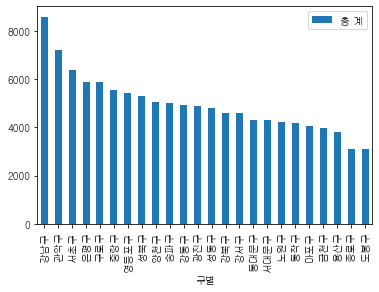

In [55]:
CCTV_POP.sort_values('총 계', ascending=False).plot(
    x='구별',
    y='총 계',
    kind='bar'
)

plt.show()

In [ ]:
CCTV_POP[['CCTV총계', '인구수대비CCTV비율']].sort_values('CCTV총계', ascending=False).plot(kind='bar')
plt.yscale('log')
plt.show() 

## 산포도(Scatter) 그리기 

In [ ]:
plt.figure(figsize=(6,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_['CCTV총계'], s=50)
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.show() 

## 경향선 그리기 

In [ ]:
fp1 = np.polyfit(CCTV_POP['인구수'], CCTV_POP['CCTV총계'], 1)

In [ ]:
f1 = np.poly1d(fp1)

In [ ]:
plt.figure(figsize=(6,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_['CCTV총계'], s=50)
plt.plot([100000, 700000], f1([100000, 700000]), 'r--')
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.show() 

In [ ]:
plt.figure(figsize=(8,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_['CCTV총계'], s=CCTV_POP['최근증가율']*5, c=CCTV_POP['외국인비율'])

for guName in CCTV_POP.index:
    x = CCTV_POP.at[guName, '인구수']
    y = CCTV_POP.at[guName, 'CCTV총계']
    plt.text(x, y, guName)
    
plt.plot([100000, 700000], f1([100000, 700000]), 'r--')
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.colorbar()
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.savefig('서울시CCTV현황.png', dpi=200)
plt.show() 

In [ ]:
CCTV_POP.to_excel('CCTV_POP.xlsx')